<a href="https://colab.research.google.com/github/Aleeha-Fatima-del/Internee.pk-projects/blob/main/Social_Media_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Social Media Performance Analysis — Internee.pk
### Instagram | Facebook | LinkedIn — Engagement Analytics Notebook

**Objective:** Extract data from Instagram, Facebook, and LinkedIn APIs, analyze likes, shares, comments and reach, and generate content strategy recommendations.




## 1️⃣ Setup & Installation

In [20]:
!pip install requests pandas plotly matplotlib seaborn --quiet
print("✅ Libraries installed")


✅ Libraries installed


In [21]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports done")


✅ Imports done


## 2️⃣ TOKENS & CONFIG ⚠️



In [22]:
# ============ FILL YOUR CREDENTIALS BELOW ============

# --- Meta (Instagram + Facebook) ---
META_ACCESS_TOKEN = "EAAcDRxZAguY8BSIqEjXFIGYv5yWR4Q6J1DACrC6JJFJPbePmplxs2tGMfafMKzhxhzFRuTAarfSjCBpx2ASc2LH8b80FfqizBZBgu16wclJD2GKUMfwlNtDGjbtQGqtZCalcZC93Q9VHKm5XiHjIg3myJuLas34U6GDuichvBBi3L6neQZBFYV6VZBu5G8"          # Facebook Page / System User Access Token
IG_BUSINESS_ACCOUNT_ID = "17841439184098388"     # Instagram Business Account ID
FB_PAGE_ID = "122099800875441163"                 # Facebook Page ID

# --- LinkedIn ---
LINKEDIN_ACCESS_TOKEN = "AQUXyGj_zOMDqXsdNA0Zkl76tNi7F8jqrlvgXmh7iWaOctRrg7R2y7x6-1o490w6UJ01uqVixSHwYREGdJogk-F-mafU7WUhUEr9rnfW85_rRKm7kCbmD-N6linF7CifJWAPoVtfkGb5bMrsi2zFBg-X8mMdKyrBJXkKRzwIVYQD6IR7MN6nyPdYj5KFk-IKEtfYzspxW_Qsk6xqF6zOj6rSMJUk0jfpe5OFoboTIkKIVaGMWCoeWJ7BnxbLq-N2ELTPiSYyfWrQ5dg4yYT24FT_ByPAlRyU3JCzqTOlQRRKOGdOHcFoKpIEh0-l0tGWpGlQNr22mOOxcXGp_i9NS0AgHqb-jg"      # LinkedIn OAuth2 Access Token (required)
LINKEDIN_ORG_ID = "135296876"            # LinkedIn Organization numeric ID
LINKEDIN_ORG_VANITY_NAME = "internee-pk"

# --- Analysis Settings ---
DAYS_TO_ANALYZE = 30            # how many days of data to analyze
USE_SIMULATED_FALLBACK = True

# =======================================================

GRAPH_API_VERSION = "v19.0"
META_BASE_URL = f"https://graph.facebook.com/{GRAPH_API_VERSION}"
LINKEDIN_BASE_URL = "https://api.linkedin.com/rest"
LINKEDIN_V2_BASE_URL = "https://api.linkedin.com/v2"

def has_meta_creds():
    return bool(META_ACCESS_TOKEN and (IG_BUSINESS_ACCOUNT_ID or FB_PAGE_ID))

def has_linkedin_creds():
    return bool(LINKEDIN_ACCESS_TOKEN)

print("Meta credentials provided:", has_meta_creds())
print("LinkedIn token provided:", has_linkedin_creds())


Meta credentials provided: True
LinkedIn token provided: True


In [23]:
def resolve_linkedin_org_id():
    """Try to auto-resolve LINKEDIN_ORG_ID using only the access token."""
    global LINKEDIN_ORG_ID

    if LINKEDIN_ORG_ID:
        print(f"✅ Using provided LINKEDIN_ORG_ID: {LINKEDIN_ORG_ID}")
        return LINKEDIN_ORG_ID

    if not LINKEDIN_ACCESS_TOKEN:
        print("⚠️ No LinkedIn access token — skipping org ID resolution")
        return None

    headers = {
        "Authorization": f"Bearer {LINKEDIN_ACCESS_TOKEN}",
        "X-Restli-Protocol-Version": "2.0.0"
    }

    # Method 1: vanity name lookup
    if LINKEDIN_ORG_VANITY_NAME:
        try:
            url = f"{LINKEDIN_V2_BASE_URL}/organizations"
            params = {"q": "vanityName", "vanityName": LINKEDIN_ORG_VANITY_NAME}
            r = requests.get(url, headers=headers, params=params, timeout=15)
            if r.ok:
                elements = r.json().get("elements", [])
                if elements:
                    org_id = str(elements[0]["id"])
                    print(f"✅ Resolved Org ID via vanity name '{LINKEDIN_ORG_VANITY_NAME}': {org_id}")
                    LINKEDIN_ORG_ID = org_id
                    return org_id
            print(f"⚠️ Vanity name lookup failed (status {r.status_code}) — token likely lacks permission")
        except Exception as e:
            print(f"⚠️ Vanity name lookup error: {e}")

    # Method 2: check admin roles on the token
    try:
        url = f"{LINKEDIN_V2_BASE_URL}/organizationAcls"
        params = {"q": "roleAssignee"}
        r = requests.get(url, headers=headers, params=params, timeout=15)
        if r.ok:
            elements = r.json().get("elements", [])
            if elements:
                org_urn = elements[0].get("organization", "")
                org_id = org_urn.split(":")[-1]
                print(f"✅ Resolved Org ID via admin role: {org_id}")
                LINKEDIN_ORG_ID = org_id
                return org_id
        print("⚠️ No admin-role organizations found on this token (expected for non-admin accounts)")
    except Exception as e:
        print(f"⚠️ Admin role lookup error: {e}")

    print("⚠️ Could not auto-resolve Org ID. Use the manual 'View Page Source' method described above, "
          "or ask your team for the numeric Org ID, then set LINKEDIN_ORG_ID manually.")
    return None

LINKEDIN_ORG_ID = resolve_linkedin_org_id() or LINKEDIN_ORG_ID

def has_linkedin_org():
    return bool(LINKEDIN_ACCESS_TOKEN and LINKEDIN_ORG_ID)


✅ Using provided LINKEDIN_ORG_ID: 135296876


## 3️⃣ Simulated Data Generator



In [24]:
def generate_simulated_data(platform, days=30):
    """Generate realistic simulated social media engagement data."""
    random.seed(hash(platform) % 1000)
    np.random.seed(hash(platform) % 1000)

    base_reach = {"Instagram": 4500, "Facebook": 3200, "LinkedIn": 1800}[platform]
    base_engagement_rate = {"Instagram": 0.045, "Facebook": 0.025, "LinkedIn": 0.035}[platform]

    rows = []
    start_date = datetime.now() - timedelta(days=days)
    content_types = {
        "Instagram": ["Reel", "Carousel", "Static Image", "Story"],
        "Facebook": ["Video", "Photo", "Link Share", "Text Post"],
        "LinkedIn": ["Article", "Document", "Image Post", "Text Update"]
    }[platform]

    for i in range(days):
        date = start_date + timedelta(days=i)
        weekday_boost = 1.25 if date.weekday() in [1, 2, 3] else 0.85  # Tue-Thu perform better
        reach = int(base_reach * weekday_boost * np.random.uniform(0.7, 1.4))
        impressions = int(reach * np.random.uniform(1.3, 1.9))

        likes = int(reach * base_engagement_rate * np.random.uniform(0.6, 1.5))
        comments = int(likes * np.random.uniform(0.03, 0.12))
        shares = int(likes * np.random.uniform(0.02, 0.10))
        saves = int(likes * np.random.uniform(0.05, 0.15)) if platform == "Instagram" else 0
        clicks = int(impressions * np.random.uniform(0.01, 0.04))

        rows.append({
            "platform": platform,
            "date": date.strftime("%Y-%m-%d"),
            "content_type": random.choice(content_types),
            "reach": reach,
            "impressions": impressions,
            "likes": likes,
            "comments": comments,
            "shares": shares,
            "saves": saves,
            "clicks": clicks,
        })

    return pd.DataFrame(rows)

print("✅ Simulated data generator ready")


✅ Simulated data generator ready


## 4️⃣ Instagram Data Fetch (Meta Graph API)
Fetches media insights (reach, likes, comments, shares, saves) for the `IG Business Account`.


In [25]:
def fetch_instagram_data(days=30):
    if not has_meta_creds() or not IG_BUSINESS_ACCOUNT_ID:
        print("⚠️ Instagram: No credentials found — using simulated data")
        return generate_simulated_data("Instagram", days), False

    try:
        # Step 1: Get recent media
        media_url = f"{META_BASE_URL}/{IG_BUSINESS_ACCOUNT_ID}/media"
        params = {
            "fields": "id,caption,media_type,timestamp,permalink",
            "access_token": META_ACCESS_TOKEN,
            "limit": 100
        }
        resp = requests.get(media_url, params=params, timeout=15)
        resp.raise_for_status()
        media_items = resp.json().get("data", [])

        cutoff = datetime.now() - timedelta(days=days)
        rows = []

        for item in media_items:
            ts = datetime.strptime(item["timestamp"][:19], "%Y-%m-%dT%H:%M:%S")
            if ts < cutoff:
                continue

            # Step 2: Get insights for each media item
            insights_url = f"{META_BASE_URL}/{item['id']}/insights"
            insight_params = {
                "metric": "reach,likes,comments,shares,saved,impressions",
                "access_token": META_ACCESS_TOKEN
            }
            ir = requests.get(insights_url, params=insight_params, timeout=15)
            metrics = {m["name"]: m["values"][0]["value"] for m in ir.json().get("data", [])} if ir.ok else {}

            rows.append({
                "platform": "Instagram",
                "date": ts.strftime("%Y-%m-%d"),
                "content_type": item.get("media_type", "IMAGE"),
                "reach": metrics.get("reach", 0),
                "impressions": metrics.get("impressions", 0),
                "likes": metrics.get("likes", 0),
                "comments": metrics.get("comments", 0),
                "shares": metrics.get("shares", 0),
                "saves": metrics.get("saved", 0),
                "clicks": 0,
            })

        if not rows:
            print("⚠️ Instagram: API returned no data — using simulated data")
            return generate_simulated_data("Instagram", days), False

        print(f"✅ Instagram: Fetched {len(rows)} real posts from Graph API")
        return pd.DataFrame(rows), True

    except Exception as e:
        print(f"⚠️ Instagram API error ({e}) — falling back to simulated data")
        return generate_simulated_data("Instagram", days), False

instagram_df, instagram_is_real = fetch_instagram_data(DAYS_TO_ANALYZE)
instagram_df.head()


⚠️ Instagram API error (400 Client Error: Bad Request for url: https://graph.facebook.com/v19.0/17841439184098388/media?fields=id%2Ccaption%2Cmedia_type%2Ctimestamp%2Cpermalink&access_token=EAAcDRxZAguY8BSIqEjXFIGYv5yWR4Q6J1DACrC6JJFJPbePmplxs2tGMfafMKzhxhzFRuTAarfSjCBpx2ASc2LH8b80FfqizBZBgu16wclJD2GKUMfwlNtDGjbtQGqtZCalcZC93Q9VHKm5XiHjIg3myJuLas34U6GDuichvBBi3L6neQZBFYV6VZBu5G8&limit=100) — falling back to simulated data


,platform,date,content_type,reach,impressions,likes,comments,shares,saves,clicks
0,Instagram,2026-07-18,Carousel,5345,7845,187,11,16,13,132
1,Instagram,2026-07-19,Story,5230,8152,151,7,3,17,126
2,Instagram,2026-07-20,Story,4959,6764,153,10,12,14,263
3,Instagram,2026-07-21,Reel,4988,9266,268,25,18,36,285
4,Instagram,2026-07-22,Carousel,7627,14006,417,39,14,46,501


## 5️⃣ Facebook Data Fetch (Meta Graph API)
Fetches Facebook Page posts and their insights (reach, engagement).


In [26]:
def fetch_facebook_data(days=30):
    if not has_meta_creds() or not FB_PAGE_ID:
        print("⚠️ Facebook: No credentials found — using simulated data")
        return generate_simulated_data("Facebook", days), False

    try:
        posts_url = f"{META_BASE_URL}/{FB_PAGE_ID}/posts"
        params = {
            "fields": "id,message,created_time,shares,"
                      "likes.summary(true),comments.summary(true)",
            "access_token": META_ACCESS_TOKEN,
            "limit": 100
        }
        resp = requests.get(posts_url, params=params, timeout=15)
        resp.raise_for_status()
        posts = resp.json().get("data", [])

        cutoff = datetime.now() - timedelta(days=days)
        rows = []

        for post in posts:
            ts = datetime.strptime(post["created_time"][:19], "%Y-%m-%dT%H:%M:%S")
            if ts < cutoff:
                continue

            insights_url = f"{META_BASE_URL}/{post['id']}/insights"
            insight_params = {
                "metric": "post_impressions,post_impressions_unique",
                "access_token": META_ACCESS_TOKEN
            }
            ir = requests.get(insights_url, params=insight_params, timeout=15)
            metrics = {m["name"]: m["values"][0]["value"] for m in ir.json().get("data", [])} if ir.ok else {}

            rows.append({
                "platform": "Facebook",
                "date": ts.strftime("%Y-%m-%d"),
                "content_type": "Post",
                "reach": metrics.get("post_impressions_unique", 0),
                "impressions": metrics.get("post_impressions", 0),
                "likes": post.get("likes", {}).get("summary", {}).get("total_count", 0),
                "comments": post.get("comments", {}).get("summary", {}).get("total_count", 0),
                "shares": post.get("shares", {}).get("count", 0),
                "saves": 0,
                "clicks": 0,
            })

        if not rows:
            print("⚠️ Facebook: API returned no data — using simulated data")
            return generate_simulated_data("Facebook", days), False

        print(f"✅ Facebook: Fetched {len(rows)} real posts from Graph API")
        return pd.DataFrame(rows), True

    except Exception as e:
        print(f"⚠️ Facebook API error ({e}) — falling back to simulated data")
        return generate_simulated_data("Facebook", days), False

facebook_df, facebook_is_real = fetch_facebook_data(DAYS_TO_ANALYZE)
facebook_df.head()


⚠️ Facebook API error (400 Client Error: Bad Request for url: https://graph.facebook.com/v19.0/122099800875441163/posts?fields=id%2Cmessage%2Ccreated_time%2Cshares%2Clikes.summary%28true%29%2Ccomments.summary%28true%29&access_token=EAAcDRxZAguY8BSIqEjXFIGYv5yWR4Q6J1DACrC6JJFJPbePmplxs2tGMfafMKzhxhzFRuTAarfSjCBpx2ASc2LH8b80FfqizBZBgu16wclJD2GKUMfwlNtDGjbtQGqtZCalcZC93Q9VHKm5XiHjIg3myJuLas34U6GDuichvBBi3L6neQZBFYV6VZBu5G8&limit=100) — falling back to simulated data


,platform,date,content_type,reach,impressions,likes,comments,shares,saves,clicks
0,Facebook,2026-07-18,Text Post,2173,3231,59,2,3,0,121
1,Facebook,2026-07-19,Link Share,2627,3614,98,9,7,0,39
2,Facebook,2026-07-20,Text Post,3446,4586,95,5,3,0,150
3,Facebook,2026-07-21,Text Post,5453,9399,196,13,13,0,282
4,Facebook,2026-07-22,Video,3019,4046,78,8,6,0,130


## 6️⃣ LinkedIn Data Fetch (LinkedIn Marketing API)
Fetches the organization's posts and their social/engagement stats.


In [27]:
def fetch_linkedin_data(days=30):
    if not has_linkedin_creds():
        print("⚠️ LinkedIn: No access token found — using simulated data")
        return generate_simulated_data("LinkedIn", days), False

    if not has_linkedin_org():
        print("⚠️ LinkedIn: Token found but no Org ID could be resolved — using simulated data.")
        print("   (See the auto-resolve cell above, or fill LINKEDIN_ORG_ID manually.)")
        return generate_simulated_data("LinkedIn", days), False

    try:
        headers = {
            "Authorization": f"Bearer {LINKEDIN_ACCESS_TOKEN}",
            "LinkedIn-Version": "202401",
            "X-Restli-Protocol-Version": "2.0.0"
        }

        posts_url = f"{LINKEDIN_BASE_URL}/posts"
        params = {
            "author": f"urn:li:organization:{LINKEDIN_ORG_ID}",
            "q": "author",
            "count": 50
        }
        resp = requests.get(posts_url, headers=headers, params=params, timeout=15)
        resp.raise_for_status()
        posts = resp.json().get("elements", [])

        cutoff = datetime.now() - timedelta(days=days)
        rows = []

        for post in posts:
            ts = datetime.fromtimestamp(post.get("createdAt", 0) / 1000)
            if ts < cutoff:
                continue

            post_id = post.get("id")
            stats_url = f"{LINKEDIN_BASE_URL}/socialActions/{post_id}"
            sr = requests.get(stats_url, headers=headers, timeout=15)
            stats = sr.json() if sr.ok else {}

            rows.append({
                "platform": "LinkedIn",
                "date": ts.strftime("%Y-%m-%d"),
                "content_type": post.get("distribution", {}).get("feedDistribution", "Post"),
                "reach": stats.get("impressionCount", 0),
                "impressions": stats.get("impressionCount", 0),
                "likes": stats.get("likesSummary", {}).get("totalLikes", 0),
                "comments": stats.get("commentsSummary", {}).get("totalComments", 0),
                "shares": stats.get("sharesSummary", {}).get("totalShares", 0),
                "saves": 0,
                "clicks": stats.get("clickCount", 0),
            })

        if not rows:
            print("⚠️ LinkedIn: API returned no data — using simulated data")
            return generate_simulated_data("LinkedIn", days), False

        print(f"✅ LinkedIn: Fetched {len(rows)} real posts from Marketing API")
        return pd.DataFrame(rows), True

    except Exception as e:
        print(f"⚠️ LinkedIn API error ({e}) — falling back to simulated data")
        return generate_simulated_data("LinkedIn", days), False

linkedin_df, linkedin_is_real = fetch_linkedin_data(DAYS_TO_ANALYZE)
linkedin_df.head()


⚠️ LinkedIn API error (426 Client Error: Upgrade Required for url: https://api.linkedin.com/rest/posts?author=urn%3Ali%3Aorganization%3A135296876&q=author&count=50) — falling back to simulated data


,platform,date,content_type,reach,impressions,likes,comments,shares,saves,clicks
0,LinkedIn,2026-07-18,Text Update,1372,2583,52,3,3,0,46
1,LinkedIn,2026-07-19,Article,1432,1961,51,3,1,0,49
2,LinkedIn,2026-07-20,Article,1172,1888,24,0,0,0,54
3,LinkedIn,2026-07-21,Image Post,2845,3818,87,7,8,0,42
4,LinkedIn,2026-07-22,Document,2521,4168,122,10,5,0,106


## 7️⃣ Combine All Platform Data

In [28]:
all_data = pd.concat([instagram_df, facebook_df, linkedin_df], ignore_index=True)
all_data["date"] = pd.to_datetime(all_data["date"])
all_data["total_engagement"] = all_data["likes"] + all_data["comments"] + all_data["shares"] + all_data["saves"]
all_data["engagement_rate"] = (all_data["total_engagement"] / all_data["reach"].replace(0, np.nan) * 100).round(2)

data_source_summary = pd.DataFrame({
    "Platform": ["Instagram", "Facebook", "LinkedIn"],
    "Data Source": [
        "Live API" if instagram_is_real else "Simulated",
        "Live API" if facebook_is_real else "Simulated",
        "Live API" if linkedin_is_real else "Simulated",
    ]
})
print(data_source_summary.to_string(index=False))
print(f"\nTotal records: {len(all_data)}")
all_data.head(10)


 Platform Data Source
Instagram   Simulated
 Facebook   Simulated
 LinkedIn   Simulated

Total records: 90


,platform,date,content_type,reach,impressions,likes,comments,shares,saves,clicks,total_engagement,engagement_rate
0,Instagram,2026-07-18,Carousel,5345,7845,187,11,16,13,132,227,4.25
1,Instagram,2026-07-19,Story,5230,8152,151,7,3,17,126,178,3.40
2,Instagram,2026-07-20,Story,4959,6764,153,10,12,14,263,189,3.81
3,Instagram,2026-07-21,Reel,4988,9266,268,25,18,36,285,347,6.96
4,Instagram,2026-07-22,Carousel,7627,14006,417,39,14,46,501,516,6.77
5,Instagram,2026-07-23,Story,4163,6712,275,11,7,25,81,318,7.64
6,Instagram,2026-07-24,Reel,2828,3883,149,14,5,17,47,185,6.54
7,Instagram,2026-07-25,Carousel,5330,9198,283,33,6,37,180,359,6.74
8,Instagram,2026-07-26,Reel,3606,5595,151,10,7,16,86,184,5.10
9,Instagram,2026-07-27,Reel,3463,6383,99,11,4,7,221,121,3.49


## 8️⃣ Overall Engagement KPIs

In [29]:
summary = all_data.groupby("platform").agg(
    total_reach=("reach", "sum"),
    total_impressions=("impressions", "sum"),
    total_likes=("likes", "sum"),
    total_comments=("comments", "sum"),
    total_shares=("shares", "sum"),
    total_saves=("saves", "sum"),
    avg_engagement_rate=("engagement_rate", "mean"),
    posts_analyzed=("date", "count")
).round(2).reset_index()

summary["total_engagement"] = summary["total_likes"] + summary["total_comments"] + summary["total_shares"] + summary["total_saves"]
summary = summary.sort_values("avg_engagement_rate", ascending=False)
summary


,platform,total_reach,total_impressions,total_likes,total_comments,total_shares,total_saves,avg_engagement_rate,posts_analyzed,total_engagement
1,Instagram,138449,221458,6523,470,340,627,5.74,30,7960
2,LinkedIn,56747,91921,1958,126,107,0,3.81,30,2191
0,Facebook,101265,156655,2887,189,187,0,3.21,30,3263


In [30]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Total Engagement by Platform", "Avg. Engagement Rate (%)"),
    specs=[[{"type": "bar"}, {"type": "bar"}]]
)

colors = {"Instagram": "#E1306C", "Facebook": "#1877F2", "LinkedIn": "#0A66C2"}

fig.add_trace(go.Bar(x=summary["platform"], y=summary["total_engagement"],
                      marker_color=[colors[p] for p in summary["platform"]], name="Engagement"), row=1, col=1)
fig.add_trace(go.Bar(x=summary["platform"], y=summary["avg_engagement_rate"],
                      marker_color=[colors[p] for p in summary["platform"]], name="Engagement Rate"), row=1, col=2)

fig.update_layout(height=450, width=950, showlegend=False, title_text="📊 Platform Performance Overview")
fig.show()


## 9️⃣ Weekly Engagement Trends

In [31]:
all_data["week"] = all_data["date"].dt.to_period("W").apply(lambda r: r.start_time)
weekly_trend = all_data.groupby(["week", "platform"])["total_engagement"].sum().reset_index()

fig = px.line(weekly_trend, x="week", y="total_engagement", color="platform",
              markers=True, color_discrete_map=colors,
              title="📈 Weekly Engagement Trend by Platform")
fig.update_layout(height=450, width=950, xaxis_title="Week", yaxis_title="Total Engagement")
fig.show()


In [32]:
daily_trend = all_data.groupby(["date", "platform"])["engagement_rate"].mean().reset_index()

fig = px.line(daily_trend, x="date", y="engagement_rate", color="platform",
              color_discrete_map=colors, title="📅 Daily Engagement Rate Trend (%)")
fig.update_layout(height=450, width=950, xaxis_title="Date", yaxis_title="Engagement Rate (%)")
fig.show()


## 🔟 Best Performing Content Types

In [33]:
content_perf = all_data.groupby(["platform", "content_type"])["engagement_rate"].mean().reset_index()
content_perf = content_perf.sort_values("engagement_rate", ascending=False)

fig = px.bar(content_perf, x="content_type", y="engagement_rate", color="platform",
             barmode="group", color_discrete_map=colors,
             title="🏆 Avg Engagement Rate by Content Type")
fig.update_layout(height=450, width=950, xaxis_title="Content Type", yaxis_title="Avg Engagement Rate (%)")
fig.show()

print("Top 5 content type combos:")
content_perf.head()


Top 5 content type combos:


,platform,content_type,engagement_rate
5,Instagram,Reel,6.321000
4,Instagram,Carousel,6.088333
6,Instagram,Static Image,5.198333
7,Instagram,Story,5.148750
11,LinkedIn,Text Update,4.075000


## 1️⃣1️⃣ Best Day to Post

In [34]:
all_data["weekday"] = all_data["date"].dt.day_name()
weekday_perf = all_data.groupby(["platform", "weekday"])["engagement_rate"].mean().reset_index()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_perf["weekday"] = pd.Categorical(weekday_perf["weekday"], categories=weekday_order, ordered=True)
weekday_perf = weekday_perf.sort_values("weekday")

fig = px.line(weekday_perf, x="weekday", y="engagement_rate", color="platform",
              markers=True, color_discrete_map=colors,
              title="📆 Engagement Rate by Day of Week")
fig.update_layout(height=450, width=950, xaxis_title="Day", yaxis_title="Avg Engagement Rate (%)")
fig.show()

best_days = weekday_perf.loc[weekday_perf.groupby("platform")["engagement_rate"].idxmax()]
print("Best posting day per platform:")
best_days[["platform", "weekday", "engagement_rate"]]


Best posting day per platform:


,platform,weekday,engagement_rate
6,Facebook,Wednesday,3.4700
12,Instagram,Tuesday,7.0375
19,LinkedIn,Tuesday,4.5300


## 1️⃣2️⃣ Metric Correlation Heatmap

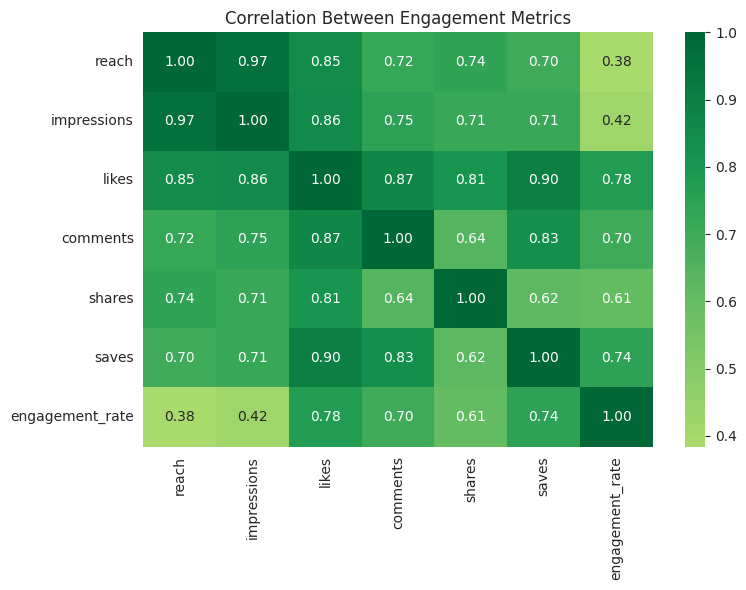

In [35]:
plt.figure(figsize=(8, 6))
corr_cols = ["reach", "impressions", "likes", "comments", "shares", "saves", "engagement_rate"]
corr = all_data[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap="RdYlGn", center=0, fmt=".2f")
plt.title("Correlation Between Engagement Metrics")
plt.tight_layout()
plt.show()


## 1️⃣3️⃣ Automated Content Strategy Recommendations

In [36]:
def generate_recommendations():
    recs = []

    top_platform = summary.iloc[0]["platform"]
    top_rate = summary.iloc[0]["avg_engagement_rate"]
    recs.append(f"🏆 **{top_platform}** has the highest average engagement rate ({top_rate}%). Prioritize content investment here.")

    for platform in ["Instagram", "Facebook", "LinkedIn"]:
        plat_content = content_perf[content_perf["platform"] == platform]
        if not plat_content.empty:
            best_type = plat_content.iloc[0]["content_type"]
            recs.append(f"📌 On **{platform}**, '{best_type}' content performs best — increase its share of the content calendar.")

    for platform in ["Instagram", "Facebook", "LinkedIn"]:
        plat_days = best_days[best_days["platform"] == platform]
        if not plat_days.empty:
            day = plat_days.iloc[0]["weekday"]
            recs.append(f"📅 Best day to post on **{platform}** is **{day}** — schedule key content around this day.")

    low_platform = summary.iloc[-1]["platform"]
    recs.append(f"⚠️ **{low_platform}** shows the lowest engagement rate — consider A/B testing captions, posting times, or formats.")

    if corr.loc["comments", "engagement_rate"] > corr.loc["likes", "engagement_rate"]:
        recs.append("💬 Comments correlate more strongly with engagement rate than likes — prioritize content that sparks conversation (questions, polls, opinions).")

    return recs

recommendations = generate_recommendations()
print("=" * 70)
print("📋 CONTENT STRATEGY RECOMMENDATIONS")
print("=" * 70)
for i, r in enumerate(recommendations, 1):
    print(f"\n{i}. {r}")


📋 CONTENT STRATEGY RECOMMENDATIONS

1. 🏆 **Instagram** has the highest average engagement rate (5.74%). Prioritize content investment here.

2. 📌 On **Instagram**, 'Reel' content performs best — increase its share of the content calendar.

3. 📌 On **Facebook**, 'Link Share' content performs best — increase its share of the content calendar.

4. 📌 On **LinkedIn**, 'Text Update' content performs best — increase its share of the content calendar.

5. 📅 Best day to post on **Instagram** is **Tuesday** — schedule key content around this day.

6. 📅 Best day to post on **Facebook** is **Wednesday** — schedule key content around this day.

7. 📅 Best day to post on **LinkedIn** is **Tuesday** — schedule key content around this day.

8. ⚠️ **Facebook** shows the lowest engagement rate — consider A/B testing captions, posting times, or formats.


## 1️⃣4️⃣ Export Results

In [37]:
all_data.to_csv("social_media_engagement_analysis.csv", index=False)
summary.to_csv("platform_summary.csv", index=False)

with open("content_strategy_recommendations.txt", "w") as f:
    f.write("SOCIAL MEDIA CONTENT STRATEGY RECOMMENDATIONS\n")
    f.write("=" * 50 + "\n\n")
    for i, r in enumerate(recommendations, 1):
        f.write(f"{i}. {r}\n\n")

print("✅ Exported:")
print("  - social_media_engagement_analysis.csv")
print("  - platform_summary.csv")
print("  - content_strategy_recommendations.txt")

# Uncomment to download in Colab:
# from google.colab import files
# files.download("social_media_engagement_analysis.csv")
# files.download("platform_summary.csv")
# files.download("content_strategy_recommendations.txt")


✅ Exported:
  - social_media_engagement_analysis.csv
  - platform_summary.csv
  - content_strategy_recommendations.txt
